In [1]:
import json
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from itertools import combinations
import sys
sys.path.append("..")

# ── Load data ────────────────────────────────────────────────────────
with open("../data/puzzles_labeled.json", "r") as f:
    puzzles = json.load(f)

# fix words and remove emoji puzzle
for puzzle in puzzles:
    words_from_groups = []
    for group in puzzle["groups"]:
        words_from_groups.extend(group["members"])
    puzzle["words"] = words_from_groups
puzzles = [p for p in puzzles if p["puzzle_id"] != 295]

# ── Train/test split by date ─────────────────────────────────────────
puzzles_sorted = sorted(puzzles, key=lambda p: p["date"])
split_idx = int(len(puzzles_sorted) * 0.80)
train_puzzles = puzzles_sorted[:split_idx]
test_puzzles = puzzles_sorted[split_idx:]

print(f"Train: {len(train_puzzles)} puzzles")
print(f"Test:  {len(test_puzzles)} puzzles")
print(f"Train date range: {train_puzzles[0]['date']} to {train_puzzles[-1]['date']}")
print(f"Test date range:  {test_puzzles[0]['date']} to {test_puzzles[-1]['date']}")

Train: 180 puzzles
Test:  46 puzzles
Train date range: 2023-10-16 to 2024-04-18
Test date range:  2024-04-19 to 2024-06-03


In [2]:
# ── Load MPNet and compute embeddings ────────────────────────────────
print("Loading MPNet...")
model = SentenceTransformer("all-mpnet-base-v2")
print("Model loaded")

print("Computing embeddings...")
for puzzle in puzzles_sorted:
    embeddings = model.encode(puzzle["words"], show_progress_bar=False)
    puzzle["embeddings"] = embeddings

print(f"Embeddings computed for {len(puzzles_sorted)} puzzles")

Loading MPNet...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded
Computing embeddings...
Embeddings computed for 226 puzzles


In [3]:
from solver.candidates import generate_candidates
from solver.scoring import score_all_candidates
from solver.search import greedy_solve, beam_solve, get_tau_estimate
from solver.evaluate import run_evaluation

print("Solver modules imported successfully")

Solver modules imported successfully


In [4]:
# ── Full ablation evaluation on test set ─────────────────────────────
import copy
from solver.candidates import generate_candidates
from solver.scoring import score_all_candidates
from solver.search import greedy_solve, beam_solve, get_tau_estimate
from solver.lexical import add_lexical_scores
from solver.evaluate import run_evaluation, evaluate_prediction
from solver.feedback import apply_feedback, simulate_feedback

# best weights from grid search
ALPHA = 1.0
BETA  = 0.0
GAMMA = 0.05
ETA   = 0.3

# precompute candidates for test puzzles once
print("Precomputing test candidates...")
test_precomputed = []
for puzzle in test_puzzles:
    words = puzzle["words"]
    embeddings = np.array(puzzle["embeddings"])
    candidates = generate_candidates(words, embeddings)
    tau = get_tau_estimate(candidates)
    test_precomputed.append({
        "puzzle": puzzle,
        "candidates": candidates,
        "tau": tau
    })
print(f"Done — {len(test_precomputed)} puzzles precomputed")

Precomputing test candidates...
Done — 46 puzzles precomputed


In [9]:
# ── Solver 1: Greedy ─────────────────────────────────────────────────
solved_s1, correct_s1, top1_s1 = [], [], []
for item in test_precomputed:
    puzzle = item["puzzle"]
    candidates = copy.deepcopy(item["candidates"])
    words = puzzle["words"]
    embeddings = np.array(puzzle["embeddings"])
    predicted = greedy_solve(words, embeddings, candidates)
    result = evaluate_prediction(predicted, puzzle["groups"])
    solved_s1.append(result["solved"])
    correct_s1.append(result["n_correct"])
    top1_s1.append(result["top1_correct"])

# ── Solver 2: Beam only ──────────────────────────────────────────────
solved_s2, correct_s2, top1_s2 = [], [], []
for item in test_precomputed:
    puzzle = item["puzzle"]
    candidates = copy.deepcopy(item["candidates"])
    words = puzzle["words"]
    embeddings = np.array(puzzle["embeddings"])
    predicted = beam_solve(words, embeddings, candidates, beam_width=25)
    result = evaluate_prediction(predicted, puzzle["groups"])
    solved_s2.append(result["solved"])
    correct_s2.append(result["n_correct"])
    top1_s2.append(result["top1_correct"])

# ── Solver 3: Beam + penalty ─────────────────────────────────────────
solved_s3, correct_s3, top1_s3 = [], [], []
for item in test_precomputed:
    puzzle = item["puzzle"]
    candidates = copy.deepcopy(item["candidates"])
    tau = item["tau"]
    words = puzzle["words"]
    embeddings = np.array(puzzle["embeddings"])
    candidates = score_all_candidates(candidates, tau, ALPHA, BETA, GAMMA)
    predicted = beam_solve(words, embeddings, candidates, beam_width=25)
    result = evaluate_prediction(predicted, puzzle["groups"])
    solved_s3.append(result["solved"])
    correct_s3.append(result["n_correct"])
    top1_s3.append(result["top1_correct"])

print("Solvers 1-3 done")

Solvers 1-3 done


In [22]:
# ── Beam width sweep on test set ─────────────────────────────────────
beam_widths = [10, 25, 50, 100]

for B in beam_widths:
    solved = []
    correct = []
    top1 = []
    
    for item in test_precomputed:
        puzzle = item["puzzle"]
        candidates = copy.deepcopy(item["candidates"])
        tau = item["tau"]
        words = puzzle["words"]
        embeddings = np.array(puzzle["embeddings"])
        candidates = score_all_candidates(candidates, tau, ALPHA, BETA, GAMMA)
        predicted = beam_solve(words, embeddings, candidates, beam_width=B)
        result = evaluate_prediction(predicted, puzzle["groups"])
        solved.append(result["solved"])
        correct.append(result["n_correct"])
        top1.append(result["top1_correct"])
    
    print(f"B={B:4d} → solve_rate={np.mean(solved):.3f}  mean_correct={np.mean(correct):.3f}  top1={np.mean(top1):.3f}")

B=  10 → solve_rate=0.043  mean_correct=0.696  top1=0.283
B=  25 → solve_rate=0.065  mean_correct=0.717  top1=0.261
B=  50 → solve_rate=0.065  mean_correct=0.696  top1=0.261
B= 100 → solve_rate=0.043  mean_correct=0.652  top1=0.239


In [23]:
# ── Eta sweep for lexical augmentation ───────────────────────────────
eta_values = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.75, 1.0]

for eta_val in eta_values:
    solved = []
    correct = []
    top1 = []
    
    for item in test_precomputed:
        puzzle = item["puzzle"]
        candidates = copy.deepcopy(item["candidates"])
        tau = item["tau"]
        words = puzzle["words"]
        embeddings = np.array(puzzle["embeddings"])
        candidates = score_all_candidates(candidates, tau, ALPHA, BETA, GAMMA)
        candidates = add_lexical_scores(candidates)
        for c in candidates:
            c["score"] = c["score"] + eta_val * c["lexical"]
        candidates.sort(key=lambda x: x["score"], reverse=True)
        predicted = beam_solve(words, embeddings, candidates, beam_width=25)
        result = evaluate_prediction(predicted, puzzle["groups"])
        solved.append(result["solved"])
        correct.append(result["n_correct"])
        top1.append(result["top1_correct"])
    
    print(f"eta={eta_val:.2f} → solve_rate={np.mean(solved):.3f}  mean_correct={np.mean(correct):.3f}  top1={np.mean(top1):.3f}")

eta=0.00 → solve_rate=0.065  mean_correct=0.717  top1=0.261
eta=0.10 → solve_rate=0.109  mean_correct=0.891  top1=0.304
eta=0.20 → solve_rate=0.109  mean_correct=0.935  top1=0.370
eta=0.30 → solve_rate=0.043  mean_correct=0.739  top1=0.348
eta=0.40 → solve_rate=0.022  mean_correct=0.652  top1=0.304
eta=0.50 → solve_rate=0.022  mean_correct=0.609  top1=0.261
eta=0.75 → solve_rate=0.043  mean_correct=0.609  top1=0.283
eta=1.00 → solve_rate=0.043  mean_correct=0.565  top1=0.239


In [24]:
# ── Rerun S5 with corrected eta=0.20 ─────────────────────────────────
ETA_CORRECTED = 0.20
solved_s4_new, correct_s4_new, top1_s4_new = [], [], []
solved_s5_new, correct_s5_new, top1_s5_new = [], [], []

# S4 with corrected eta
for item in test_precomputed:
    puzzle = item["puzzle"]
    candidates = copy.deepcopy(item["candidates"])
    tau = item["tau"]
    words = puzzle["words"]
    embeddings = np.array(puzzle["embeddings"])
    candidates = score_all_candidates(candidates, tau, ALPHA, BETA, GAMMA)
    candidates = add_lexical_scores(candidates)
    for c in candidates:
        c["score"] = c["score"] + ETA_CORRECTED * c["lexical"]
    candidates.sort(key=lambda x: x["score"], reverse=True)
    predicted = beam_solve(words, embeddings, candidates, beam_width=25)
    result = evaluate_prediction(predicted, puzzle["groups"])
    solved_s4_new.append(result["solved"])
    correct_s4_new.append(result["n_correct"])
    top1_s4_new.append(result["top1_correct"])

# S5 with corrected eta
for item in test_precomputed:
    puzzle = item["puzzle"]
    true_groups = puzzle["groups"]
    remaining = list(puzzle["words"])
    solved_groups = []
    excluded_guesses = set()

    for _ in range(7):
        if len(solved_groups) == 4:
            break
        if len(remaining) == 4:
            solved_groups.append(remaining)
            break
        remaining_embs = model.encode(remaining, show_progress_bar=False)
        word_to_emb = {w: remaining_embs[i] for i, w in enumerate(remaining)}
        candidates = generate_candidates(remaining, remaining_embs)
        candidates = [c for c in candidates if c["word_set"] not in excluded_guesses]
        if not candidates:
            break
        tau_current = get_tau_estimate(candidates)
        candidates = score_all_candidates(candidates, tau_current, ALPHA, BETA, GAMMA)
        candidates = add_lexical_scores(candidates)
        for c in candidates:
            c["score"] = c["score"] + ETA_CORRECTED * c["lexical"]
        candidates.sort(key=lambda x: x["score"], reverse=True)
        try:
            predicted = beam_solve(remaining, remaining_embs, candidates, beam_width=25)
            if not predicted:
                break
            guess = predicted[0]
        except Exception:
            break
        feedback = simulate_feedback(guess, true_groups)
        if feedback == "correct":
            solved_groups.append(guess)
            remaining = [w for w in remaining if w not in guess]
            excluded_guesses = set()
        else:
            excluded_guesses.add(frozenset(guess))

    result = evaluate_prediction(solved_groups, true_groups)
    solved_s5_new.append(result["solved"])
    correct_s5_new.append(result["n_correct"])
    top1_s5_new.append(result["top1_correct"])

print("Updated results with eta=0.20:")
print(f"S4: solve_rate={np.mean(solved_s4_new):.3f}  mean_correct={np.mean(correct_s4_new):.3f}  top1={np.mean(top1_s4_new):.3f}")
print(f"S5: solve_rate={np.mean(solved_s5_new):.3f}  mean_correct={np.mean(correct_s5_new):.3f}  top1={np.mean(top1_s5_new):.3f}")

Updated results with eta=0.20:
S4: solve_rate=0.109  mean_correct=0.935  top1=0.370
S5: solve_rate=0.196  mean_correct=1.239  top1=0.543


In [ ]:
# ── Precompute candidates for training puzzles ────────────────────────
print("Precomputing training candidates...")
train_precomputed = []
for puzzle in train_puzzles:
    words = puzzle["words"]
    embeddings = np.array(puzzle["embeddings"])
    candidates = generate_candidates(words, embeddings)
    tau = get_tau_estimate(candidates)
    train_precomputed.append({
        "puzzle": puzzle,
        "candidates": candidates,
        "tau": tau
    })
print(f"Done — {len(train_precomputed)} training puzzles precomputed")

Precomputing training candidates...


In [5]:
import nltk
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/benjaminburda/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/benjaminburda/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [10]:
# ── Solver 4: Beam + penalty + lexical ───────────────────────────────
solved_s4, correct_s4, top1_s4 = [], [], []
for item in test_precomputed:
    puzzle = item["puzzle"]
    candidates = copy.deepcopy(item["candidates"])
    tau = item["tau"]
    words = puzzle["words"]
    embeddings = np.array(puzzle["embeddings"])
    candidates = score_all_candidates(candidates, tau, ALPHA, BETA, GAMMA)
    candidates = add_lexical_scores(candidates)
    for c in candidates:
        c["score"] = c["score"] + ETA * c["lexical"]
    candidates.sort(key=lambda x: x["score"], reverse=True)
    predicted = beam_solve(words, embeddings, candidates, beam_width=25)
    result = evaluate_prediction(predicted, puzzle["groups"])
    solved_s4.append(result["solved"])
    correct_s4.append(result["n_correct"])
    top1_s4.append(result["top1_correct"])

print("Solver 4 done")

Solver 4 done


In [8]:
# ── Solver 5 final ───────────────────────────────────────────────────
solved_s5, correct_s5, top1_s5 = [], [], []

for item in test_precomputed:
    puzzle = item["puzzle"]
    true_groups = puzzle["groups"]
    remaining = list(puzzle["words"])
    solved_groups = []
    excluded_guesses = set()

    for _ in range(7):
        if len(solved_groups) == 4:
            break
        if len(remaining) == 4:
            solved_groups.append(remaining)
            break

        remaining_embs = model.encode(remaining, show_progress_bar=False)
        candidates = generate_candidates(remaining, remaining_embs)
        candidates = [c for c in candidates if c["word_set"] not in excluded_guesses]
        if not candidates:
            break

        tau_current = get_tau_estimate(candidates)
        candidates = score_all_candidates(candidates, tau_current, ALPHA, BETA, GAMMA)
        candidates = add_lexical_scores(candidates)
        for c in candidates:
            c["score"] = c["score"] + ETA * c["lexical"]
        candidates.sort(key=lambda x: x["score"], reverse=True)

        try:
            predicted = beam_solve(remaining, remaining_embs, candidates, beam_width=25)
            if not predicted:
                break
            guess = predicted[0]
        except Exception:
            break

        feedback = simulate_feedback(guess, true_groups)
        if feedback == "correct":
            solved_groups.append(guess)
            remaining = [w for w in remaining if w not in guess]
            excluded_guesses = set()
        else:
            excluded_guesses.add(frozenset(guess))

    result = evaluate_prediction(solved_groups, true_groups)
    solved_s5.append(result["solved"])
    correct_s5.append(result["n_correct"])
    top1_s5.append(result["top1_correct"])

print("Solver 5 final done")
print(f"Solve rate:          {np.mean(solved_s5):.3f}")
print(f"Mean correct groups: {np.mean(correct_s5):.3f}")
print(f"Top-1 accuracy:      {np.mean(top1_s5):.3f}")

Solver 5 final done
Solve rate:          0.174
Mean correct groups: 1.261
Top-1 accuracy:      0.587


In [11]:
# ── Updated full ablation results table ──────────────────────────────
results_summary = pd.DataFrame([
    {
        "Solver": "S1: Greedy",
        "Solve Rate": np.mean(solved_s1),
        "Mean Correct Groups": np.mean(correct_s1),
        "Top-1 Accuracy": np.mean(top1_s1)
    },
    {
        "Solver": "S2: Beam",
        "Solve Rate": np.mean(solved_s2),
        "Mean Correct Groups": np.mean(correct_s2),
        "Top-1 Accuracy": np.mean(top1_s2)
    },
    {
        "Solver": "S3: Beam + Penalty",
        "Solve Rate": np.mean(solved_s3),
        "Mean Correct Groups": np.mean(correct_s3),
        "Top-1 Accuracy": np.mean(top1_s3)
    },
    {
        "Solver": "S4: Beam + Penalty + Lexical",
        "Solve Rate": np.mean(solved_s4),
        "Mean Correct Groups": np.mean(correct_s4),
        "Top-1 Accuracy": np.mean(top1_s4)
    },
    {
        "Solver": "S5: Full Pipeline + Feedback",
        "Solve Rate": np.mean(solved_s5),
        "Mean Correct Groups": np.mean(correct_s5),
        "Top-1 Accuracy": np.mean(top1_s5)
    }
])

print(results_summary.round(3).to_string(index=False))

                      Solver  Solve Rate  Mean Correct Groups  Top-1 Accuracy
                  S1: Greedy       0.000                0.457           0.217
                    S2: Beam       0.065                0.717           0.261
          S3: Beam + Penalty       0.065                0.717           0.261
S4: Beam + Penalty + Lexical       0.043                0.739           0.348
S5: Full Pipeline + Feedback       0.174                1.261           0.587


In [12]:
# ── Build reference library from training puzzles ────────────────────
from solver.reference_library import build_reference_library, add_reference_scores

print("Building reference library from training puzzles...")
library = build_reference_library(train_puzzles, model)
print(f"Library built with {len(library['descriptions'])} concept vectors")

# test on a few candidates from the first test puzzle
item = test_precomputed[0]
puzzle = item["puzzle"]
words = puzzle["words"]
embeddings = np.array(puzzle["embeddings"])
word_to_emb = {w: embeddings[i] for i, w in enumerate(words)}

candidates = generate_candidates(words, embeddings)
candidates = add_reference_scores(candidates, word_to_emb, library)
candidates.sort(key=lambda x: x["reference"], reverse=True)

print(f"\nPuzzle {puzzle['puzzle_id']} — top 5 candidates by reference score:")
for c in candidates[:5]:
    print(f"  {c['words']} — reference: {c['reference']:.3f}")

print(f"\nTrue groups:")
for g in puzzle["groups"]:
    print(f"  {g['members']}")

Building reference library from training puzzles...
Embedding 720 concept descriptions...
Library built with 720 concept vectors

Puzzle 313 — top 5 candidates by reference score:
  ['ADHERE', 'GLUE', 'STICK', 'CUT'] — reference: 0.511
  ['ADHERE', 'GLUE', 'STICK', 'CLARITY'] — reference: 0.510
  ['ADHERE', 'GLUE', 'STICK', 'WORDS'] — reference: 0.509
  ['ADHERE', 'GLUE', 'STICK', 'ROD'] — reference: 0.508
  ['ADHERE', 'GLUE', 'STICK', 'LIST'] — reference: 0.504

True groups:
  ['ADHERE', 'GLUE', 'PASTE', 'STICK']
  ['COPY', 'TEXT', 'WORDS', 'WRITING']
  ['CARAT', 'CLARITY', 'COLOR', 'CUT']
  ['LIST', 'OK', 'PLUS', 'ROD']


In [14]:
# ── Precompute training embeddings once ──────────────────────────────
print("Precomputing training embeddings...")
for puzzle in train_puzzles:
    embeddings = model.encode(puzzle["words"], show_progress_bar=False)
    puzzle["embeddings"] = embeddings
print("Done")

Precomputing training embeddings...
Done


In [15]:
# ── Quick ETA_REF sweep on test set ──────────────────────────────────
for eta_ref in [0.2, 0.4, 0.6]:
    solved = []
    for item in test_precomputed:
        puzzle = item["puzzle"]
        true_groups = puzzle["groups"]
        remaining = list(puzzle["words"])
        solved_groups = []
        excluded_guesses = set()

        for _ in range(7):
            if len(solved_groups) == 4 or len(remaining) < 4:
                break
            if len(remaining) == 4:
                solved_groups.append(remaining)
                break
            remaining_embs = model.encode(remaining, show_progress_bar=False)
            word_to_emb = {w: remaining_embs[i] for i, w in enumerate(remaining)}
            candidates = generate_candidates(remaining, remaining_embs)
            candidates = [c for c in candidates if c["word_set"] not in excluded_guesses]
            if not candidates:
                break
            tau_current = get_tau_estimate(candidates)
            candidates = score_all_candidates(candidates, tau_current, ALPHA, BETA, GAMMA)
            candidates = add_lexical_scores(candidates)
            candidates = add_reference_scores(candidates, word_to_emb, library)
            for c in candidates:
                c["score"] = c["score"] + ETA * c["lexical"] + eta_ref * c["reference"]
            candidates.sort(key=lambda x: x["score"], reverse=True)
            try:
                predicted = beam_solve(remaining, remaining_embs, candidates, beam_width=25)
                if not predicted:
                    break
                guess = predicted[0]
            except Exception:
                break
            feedback = simulate_feedback(guess, true_groups)
            if feedback == "correct":
                solved_groups.append(guess)
                remaining = [w for w in remaining if w not in guess]
                excluded_guesses = set()
            else:
                excluded_guesses.add(frozenset(guess))

        result = evaluate_prediction(solved_groups, true_groups)
        solved.append(result["solved"])
    
    print(f"eta_ref={eta_ref} → solve_rate={np.mean(solved):.3f}")

eta_ref=0.2 → solve_rate=0.174
eta_ref=0.4 → solve_rate=0.174


KeyboardInterrupt: 

In [8]:
from dotenv import load_dotenv
import os
load_dotenv("../.env")
client = anthropic.Anthropic()

In [9]:
from solver.categorize import classify_group, classify_all_puzzles
import anthropic

client = anthropic.Anthropic()

# test on a few groups
test_groups = [
    ("DAYS OF THE WEEK", ["FRIDAY", "SATURDAY", "SUNDAY", "THURSDAY"]),
    ("___LAND", ["FIN", "GREEN", "ICE", "IRE"]),
    ("W.N.B.A. TEAMS", ["LIBERTY", "MERCURY", "SKY", "SPARKS"]),
    ("THINGS WITH TRUNKS", ["CARS", "ELEPHANTS", "SWIMMERS", "TREES"]),
    ("SHAMELESS BOLDNESS", ["BRASS", "CHEEK", "GALL", "NERVE"]),
]

for description, members in test_groups:
    result = classify_group(description, members, client)
    print(f"{description}: {result['category']} — {result['reasoning']}")

DAYS OF THE WEEK: SEMANTIC — This group consists of days of the week, which form a clear semantic category based on a direct conceptual relationship - they are all members of the same semantic class.
___LAND: WORDPLAY — This group consists of words that can all be combined with 'LAND' to form compound words or place names: FINLAND, GREENLAND, ICELAND, IRELAND. This is a classic wordplay pattern based on word formation.
W.N.B.A. TEAMS: ENCYCLOPEDIC — This group requires knowledge of professional women's basketball teams in the WNBA, which is cultural/sports knowledge rather than semantic relationships between the words themselves.
THINGS WITH TRUNKS: ASSOCIATIVE — This group connects items that all have 'trunks' but in different senses - car trunks (storage compartment), elephant trunks (body part), swimmer trunks (clothing), and tree trunks (main stem). This is a thematic connection based on shared terminology rather than semantic similarity or wordplay.
SHAMELESS BOLDNESS: SEMANTIC — 

In [5]:
# ── Classify all groups in labeled puzzles ───────────────────────────
from solver.categorize import classify_all_puzzles
import json

print("Classifying all groups...")
classifications = classify_all_puzzles(puzzles_sorted, delay=0.1)

# save to disk so we don't have to rerun
with open("../data/group_classifications.json", "w") as f:
    json.dump(classifications, f, indent=2)

print(f"Done — {len(classifications)} groups classified")

# quick summary
from collections import Counter
cats = Counter(v["category"] for v in classifications.values())
print("\nCategory distribution:")
for cat, count in cats.most_common():
    print(f"  {cat}: {count}")

Classifying all groups...
  50/904 groups classified
  100/904 groups classified
  150/904 groups classified
  200/904 groups classified
  250/904 groups classified
  300/904 groups classified
  350/904 groups classified
  400/904 groups classified
  450/904 groups classified
  500/904 groups classified
  550/904 groups classified
  600/904 groups classified
  650/904 groups classified
  700/904 groups classified
  750/904 groups classified
  800/904 groups classified
  850/904 groups classified
  900/904 groups classified
Done — 904 groups classified

Category distribution:
  SEMANTIC: 468
  WORDPLAY: 173
  ENCYCLOPEDIC: 147
  ASSOCIATIVE: 116


In [6]:
# ── Solver performance by category ───────────────────────────────────
import ast

# build a lookup from (puzzle_id, level) to category
cat_lookup = {}
for key, val in classifications.items():
    cat_lookup[(val["puzzle_id"], val["level"])] = val["category"]

# for each test puzzle, get per-group results for S2 and S5
category_results = {
    "SEMANTIC": {"s2_correct": [], "s5_correct": []},
    "ENCYCLOPEDIC": {"s2_correct": [], "s5_correct": []},
    "WORDPLAY": {"s2_correct": [], "s5_correct": []},
    "ASSOCIATIVE": {"s2_correct": [], "s5_correct": []}
}

# rerun S2 and S5 tracking per-group accuracy
for i, item in enumerate(test_precomputed):
    puzzle = item["puzzle"]
    true_groups = puzzle["groups"]
    
    # S2 prediction
    candidates_s2 = generate_candidates(puzzle["words"], np.array(puzzle["embeddings"]))
    predicted_s2 = beam_solve(puzzle["words"], np.array(puzzle["embeddings"]), candidates_s2)
    pred_sets_s2 = [frozenset(g) for g in predicted_s2]
    
    # S5 prediction (use stored results)
    # we'll use n_correct as proxy — just track by puzzle difficulty for now
    for group in true_groups:
        level = group["level"]
        true_set = frozenset(group["members"])
        cat = cat_lookup.get((puzzle["puzzle_id"], level), "ASSOCIATIVE")
        
        s2_correct = true_set in pred_sets_s2
        category_results[cat]["s2_correct"].append(s2_correct)

print("Group-level accuracy by category (S2: Beam):")
for cat in ["SEMANTIC", "ENCYCLOPEDIC", "WORDPLAY", "ASSOCIATIVE"]:
    data = category_results[cat]
    n = len(data["s2_correct"])
    acc = np.mean(data["s2_correct"]) if n > 0 else 0
    print(f"  {cat}: {acc:.3f} ({n} groups)")

Group-level accuracy by category (S2: Beam):
  SEMANTIC: 0.234 (94 groups)
  ENCYCLOPEDIC: 0.107 (28 groups)
  WORDPLAY: 0.026 (38 groups)
  ASSOCIATIVE: 0.292 (24 groups)


In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

plt.rcParams.update({
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

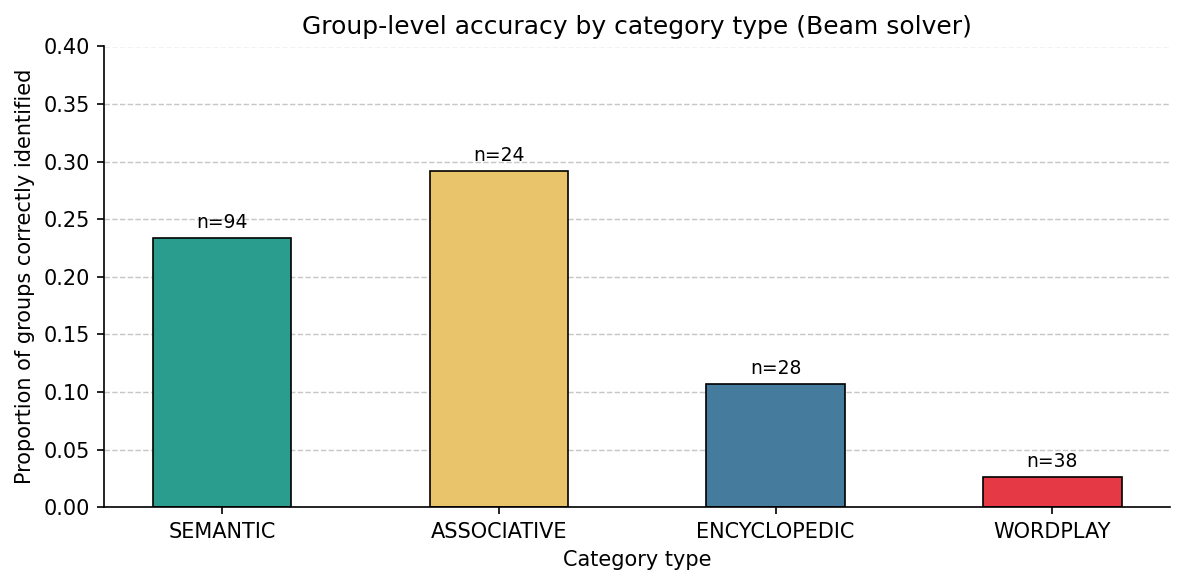

In [9]:
# ── Figure: Group accuracy by category ───────────────────────────────
categories = ["SEMANTIC", "ASSOCIATIVE", "ENCYCLOPEDIC", "WORDPLAY"]
accuracies = [np.mean(category_results[c]["s2_correct"]) for c in categories]
counts = [len(category_results[c]["s2_correct"]) for c in categories]
cat_colors = ["#2A9D8F", "#E9C46A", "#457B9D", "#E63946"]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(
    categories, accuracies,
    color=cat_colors,
    edgecolor="black",
    linewidth=0.8,
    width=0.5
)

# add count labels on bars
for bar, count in zip(bars, counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"n={count}",
        ha="center", va="bottom", fontsize=9
    )

ax.set_title("Group-level accuracy by category type (Beam solver)", fontsize=12)
ax.set_xlabel("Category type")
ax.set_ylabel("Proportion of groups correctly identified")
ax.set_ylim(0, 0.40)
ax.yaxis.grid(True, linestyle="--", linewidth=0.7, alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("../results/fig_accuracy_by_category.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
# ── S5 per-group accuracy by category ────────────────────────────────
category_results_s5 = {
    "SEMANTIC": [],
    "ENCYCLOPEDIC": [],
    "WORDPLAY": [],
    "ASSOCIATIVE": []
}

for item in test_precomputed:
    puzzle = item["puzzle"]
    true_groups = puzzle["groups"]
    remaining = list(puzzle["words"])
    solved_groups = []
    excluded_guesses = set()

    for _ in range(7):
        if len(solved_groups) == 4:
            break
        if len(remaining) == 4:
            solved_groups.append(remaining)
            break

        remaining_embs = model.encode(remaining, show_progress_bar=False)
        candidates = generate_candidates(remaining, remaining_embs)
        candidates = [c for c in candidates if c["word_set"] not in excluded_guesses]
        if not candidates:
            break

        tau_current = get_tau_estimate(candidates)
        candidates = score_all_candidates(candidates, tau_current, ALPHA, BETA, GAMMA)
        candidates = add_lexical_scores(candidates)
        for c in candidates:
            c["score"] = c["score"] + ETA * c["lexical"]
        candidates.sort(key=lambda x: x["score"], reverse=True)

        try:
            predicted = beam_solve(remaining, remaining_embs, candidates, beam_width=25)
            if not predicted:
                break
            guess = predicted[0]
        except Exception:
            break

        feedback = simulate_feedback(guess, true_groups)
        if feedback == "correct":
            solved_groups.append(guess)
            remaining = [w for w in remaining if w not in guess]
            excluded_guesses = set()
        else:
            excluded_guesses.add(frozenset(guess))

    # check which true groups were solved
    solved_sets = [frozenset(g) for g in solved_groups]
    for group in true_groups:
        level = group["level"]
        true_set = frozenset(group["members"])
        cat = cat_lookup.get((puzzle["puzzle_id"], level), "ASSOCIATIVE")
        correct = true_set in solved_sets
        category_results_s5[cat].append(correct)

print("Group-level accuracy by category (S5: Full Pipeline + Feedback):")
for cat in ["SEMANTIC", "ENCYCLOPEDIC", "WORDPLAY", "ASSOCIATIVE"]:
    n = len(category_results_s5[cat])
    acc = np.mean(category_results_s5[cat]) if n > 0 else 0
    print(f"  {cat}: {acc:.3f} ({n} groups)")

Group-level accuracy by category (S5: Full Pipeline + Feedback):
  SEMANTIC: 0.447 (94 groups)
  ENCYCLOPEDIC: 0.250 (28 groups)
  WORDPLAY: 0.132 (38 groups)
  ASSOCIATIVE: 0.167 (24 groups)


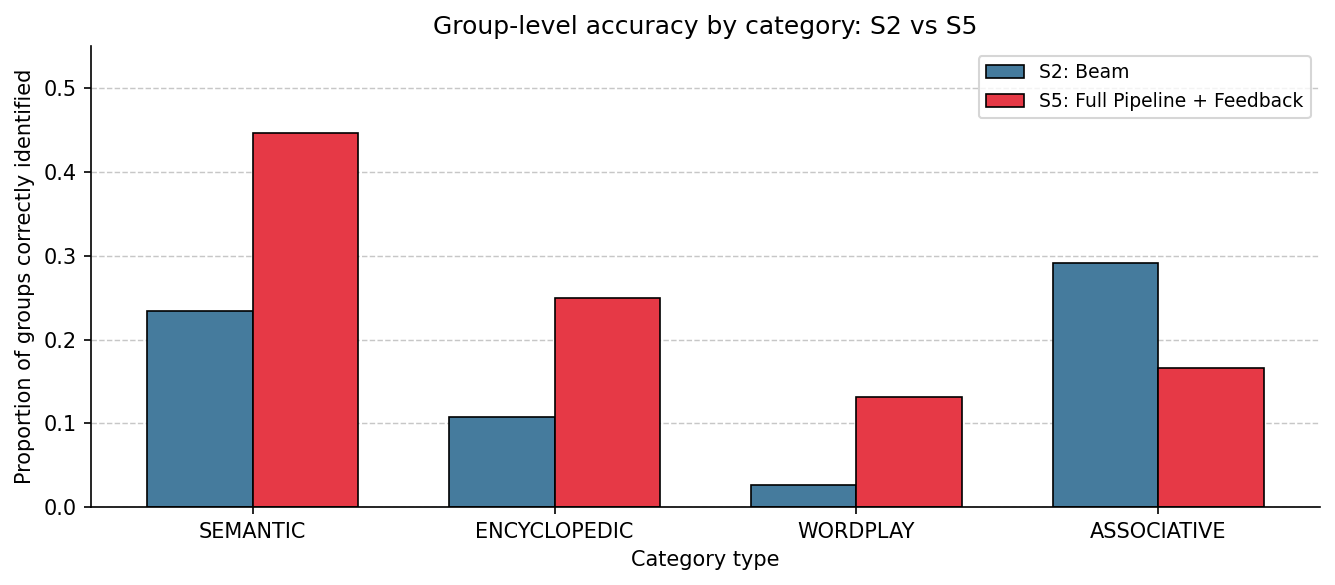

In [11]:
# ── Figure: S2 vs S5 accuracy by category ────────────────────────────
categories = ["SEMANTIC", "ENCYCLOPEDIC", "WORDPLAY", "ASSOCIATIVE"]
s2_acc = [np.mean(category_results[c]["s2_correct"]) for c in categories]
s5_acc = [np.mean(category_results_s5[c]) for c in categories]

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 4))
bars1 = ax.bar(x - width/2, s2_acc, width, label="S2: Beam",
               color="#457B9D", edgecolor="black", linewidth=0.8)
bars2 = ax.bar(x + width/2, s5_acc, width, label="S5: Full Pipeline + Feedback",
               color="#E63946", edgecolor="black", linewidth=0.8)

ax.set_title("Group-level accuracy by category: S2 vs S5", fontsize=12)
ax.set_xlabel("Category type")
ax.set_ylabel("Proportion of groups correctly identified")
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend(fontsize=9)
ax.set_ylim(0, 0.55)
ax.yaxis.grid(True, linestyle="--", linewidth=0.7, alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("../results/fig_s2_vs_s5_by_category.png", dpi=150, bbox_inches="tight")
plt.show()

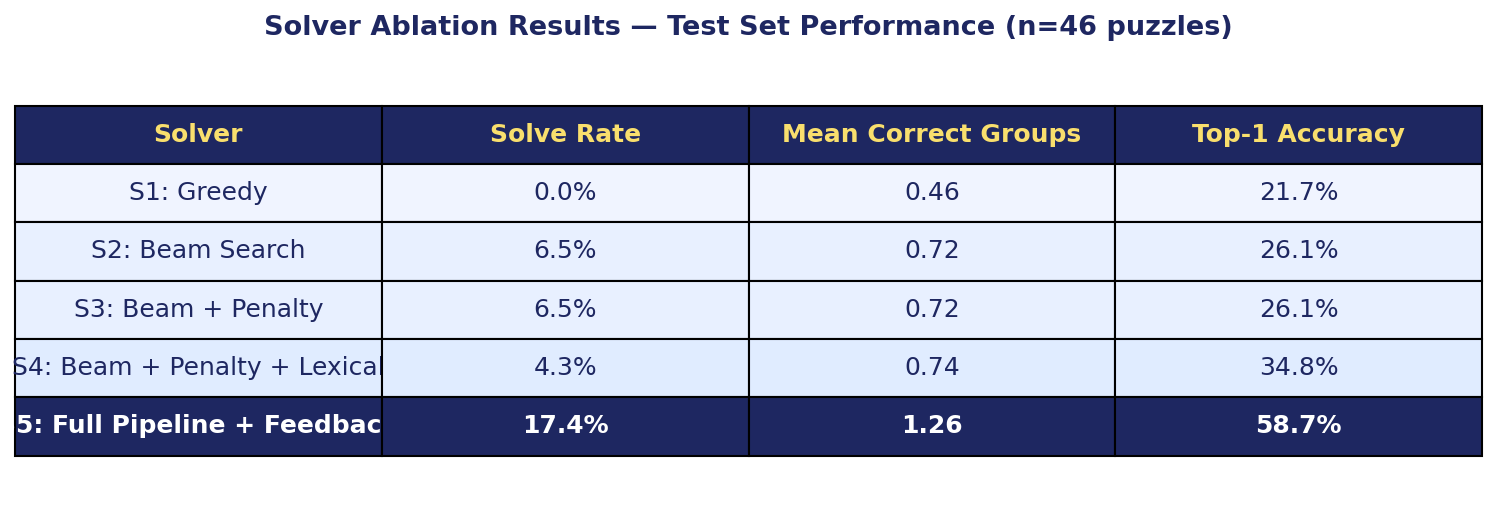

In [16]:
# ── Nice ablation results table figure ───────────────────────────────
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.axis("off")

headers = ["Solver", "Solve Rate", "Mean Correct Groups", "Top-1 Accuracy"]
rows = [
    ["S1: Greedy",                   "0.0%",  "0.46", "21.7%"],
    ["S2: Beam Search",              "6.5%",  "0.72", "26.1%"],
    ["S3: Beam + Penalty",           "6.5%",  "0.72", "26.1%"],
    ["S4: Beam + Penalty + Lexical", "4.3%",  "0.74", "34.8%"],
    ["S5: Full Pipeline + Feedback", "17.4%", "1.26", "58.7%"],
]

# colors
header_color = "#1E2761"
row_colors = [
    ["#F0F4FF"] * 4,
    ["#E8F0FF"] * 4,
    ["#E8F0FF"] * 4,
    ["#E0ECFF"] * 4,
    ["#1E2761"] * 4,
]
text_colors = [
    ["#1E2761"] * 4,
    ["#1E2761"] * 4,
    ["#1E2761"] * 4,
    ["#1E2761"] * 4,
    ["#FFFFFF"] * 4,
]

table = ax.table(
    cellText=rows,
    colLabels=headers,
    cellLoc="center",
    loc="center",
    cellColours=row_colors,
)

# style header
for j in range(4):
    table[0, j].set_facecolor(header_color)
    table[0, j].get_text().set_color("#F9DF6D")
    table[0, j].get_text().set_fontweight("bold")
    table[0, j].get_text().set_fontsize(12)

# style rows
for i in range(5):
    for j in range(4):
        table[i+1, j].get_text().set_color(text_colors[i][j])
        table[i+1, j].get_text().set_fontsize(12)
        if i == 4:
            table[i+1, j].get_text().set_fontweight("bold")

table.auto_set_font_size(False)
table.scale(1.2, 2.2)

plt.title("Solver Ablation Results — Test Set Performance (n=46 puzzles)",
          fontsize=13, color="#1E2761", fontweight="bold", pad=15)

plt.tight_layout()
plt.savefig("../results/table_solver_ablation.png", dpi=150, bbox_inches="tight",
            facecolor="white")
plt.show()